## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Food Recommendation System</p>

<a id="toc"></a>

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Content</p>

* [INTRODUCTION](#0)
* [IMPORTING MODULES, LOADING DATA & DATA REVIEW](#1)
* [PREPROCESSING](#2)
* [EXPLORATORY DATA ANALYSIS (EDA)](#3)    
* [SCALING, CATEGORICAL VARIABLES, SPLITTING](#4)
* [MODELS](#5)
* [CONCLUSION](#6)

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Introduction</p>

<a id="0"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true"
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 1.1 Information About the Project

**Objective:**  
The primary objective of this project is to develop a recommendation system for a large food company to mitigate customer information overload. Since the dataset contains no explicit ratings, the core challenge is to build, compare, and evaluate multiple recommendation approaches by deriving implicit customer preferences from their transactional behavior.

**Scope:**  
This project goes beyond simply writing code; it focuses on thinking like a data scientist by making strategic decisions, evaluating trade-offs, and justifying choices with evidence. The scope encompasses:

* Exploring and preprocessing real-world, sparse data.

* Engineering an implicit rating strategy based on factors like frequency, spending, or recency.

* Implementing and comparing at least two different recommendation approaches (e.g., User-Based Collaborative Filtering, Item-Based Collaborative Filtering, Popularity Baseline).

* Evaluating methods using ranking metrics like Precision and Recall rather than traditional error metrics.

* Connecting the technical results to business value through deployment recommendations and addressing business constraints.

## 1.2 Description of the Dataset

- **Source:** The dataset (recom.csv) is a real transactional dataset provided by a large food company.

- **Size:** It contains approximately 50,000 transactions from 28,514 unique customers across 152 unique items.

- **Type:** This is tabular transactional data containing implicit feedback, collected over a 3-month period (August 26 to December 3, 2022). It is characterized by extreme sparsity (the median customer has only 1 transaction) and a high variance in item popularity.

## 1.3 Description of the Columns

- **Target Variable:** There is NO explicit target variable (like stars or numerical scores) in this dataset. Instead, an implicit rating is engineered using the behavioral signals provided in the data, such as purchase frequency, recency, spending, or simple binary purchase signals.

- **Feature Variables:** 

    * Main ID: The customer identifier (representing 28,514 unique customers)

    * Transaction ID: The unique identifier for each transaction.

    * Date: The transaction timestamp (August 26 - December 3, 2022).

    * Price: The price of the purchased item, ranging from $0.50 to $2,525.50.

    * Code Product: The product code, which represents 333 unique products.

    * Amount: The quantity of items purchased in the transaction, ranging from 1 to 54 units.

    * ItemKey: The item identifier for 152 unique items. Note: 43% of these values are missing and will require a strategic handling decision.


## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Importing Modules, Load Data & Data Review</p>

<a id="1"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

In [261]:
import random
import warnings
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [262]:
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [263]:
# load the data
df = pd.read_csv('recom.csv')

df.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
Main_ID,90fada91,9006f9ac,32270891,97e03e47,41949228
Transaction_ID,264f7a69,45c7d853,61ad76dd,41ee09f6,244fe6d8
Date,2022-10-07 20:53:49.153,2022-09-17 15:54:57.187,2022-11-28 13:51:55.667,2022-09-12 16:20:22.110,2022-10-14 18:53:43.933
Price,125.0,19.0,141.0,4.5,129.5
Code_Product,5002.0,35012.0,5005.0,35078.5,49291.5
Amount,1.0,1.0,1.0,1.0,5.0
ItemKey,5002.0,NaN,5005.0,NaN,NaN


In [264]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      50000 non-null  int64  
 1   Main_ID         50000 non-null  str    
 2   Transaction_ID  50000 non-null  str    
 3   Date            50000 non-null  str    
 4   Price           50000 non-null  float64
 5   Code_Product    50000 non-null  float64
 6   Amount          50000 non-null  float64
 7   ItemKey         28597 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 3.1 MB


In [265]:
df.nunique()

Unnamed: 0        50000
Main_ID           28514
Transaction_ID    48403
Date              48398
Price               795
Code_Product        333
Amount               22
ItemKey             152
dtype: int64

In [266]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50000.0,24999.500000,14433.901067,0.0,12499.75,24999.5,37499.25,49999.0
Price,50000.0,62.560670,68.269624,0.5,24.50,45.5,83.00,2525.5
Code_Product,50000.0,32379.293540,21697.500334,5000.5,10013.00,40009.5,49291.50,350027.5
Amount,50000.0,1.232640,0.749353,1.0,1.00,1.0,1.00,54.0
ItemKey,28597.0,20775.740952,16481.882853,5000.5,5011.50,10023.0,40028.50,57035.5


In [267]:
df.duplicated().sum()

np.int64(0)

### Key Questions and Answer

1. How many unique customers?

In [268]:
print('Main_ID:', df['Main_ID'].nunique())

Main_ID: 28514


2. How many unique items (ItemKey vs Code_Product)?

In [269]:
print('ItemKey:', df['ItemKey'].nunique())
print('Code_Product:', df['Code_Product'].nunique())

ItemKey: 152
Code_Product: 333


3. Distribution of purchases per customer?

count    28514.000000
mean         1.697517
std          2.182692
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         44.000000
Name: Transaction_ID, dtype: float64
Percentage of customers with <= 2 transactions: 88.02%


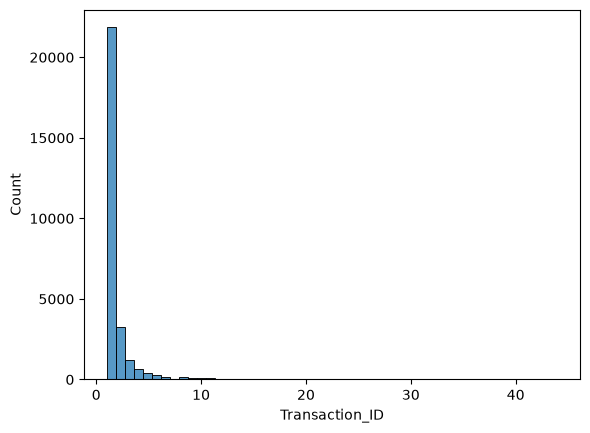

In [270]:
purchases_per_customer = df.groupby('Main_ID')['Transaction_ID'].nunique()

sns.histplot(purchases_per_customer, bins=50)

print(purchases_per_customer.describe())

percentage = (purchases_per_customer <= 2).mean() * 100
print(f"Percentage of customers with <= 2 transactions: {percentage:.2f}%")

4. Distribution of purchases per item?

count     152.000000
mean      187.447368
std       455.026363
min         1.000000
25%         7.750000
50%        33.500000
75%       156.250000
max      3781.000000
Name: Transaction_ID, dtype: float64

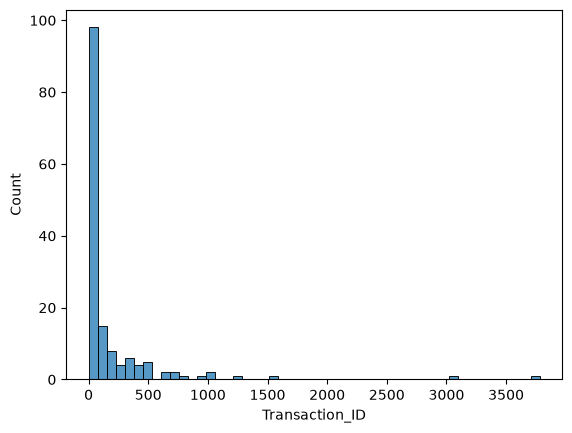

In [271]:
purchases_per_item = df.groupby('ItemKey')['Transaction_ID'].nunique()

sns.histplot(purchases_per_item, bins=50)

purchases_per_item.describe()

5. How many missing ItemKey values?

In [272]:
df['ItemKey'].isnull().sum()

np.int64(21403)

6. Date range and temporal patterns?

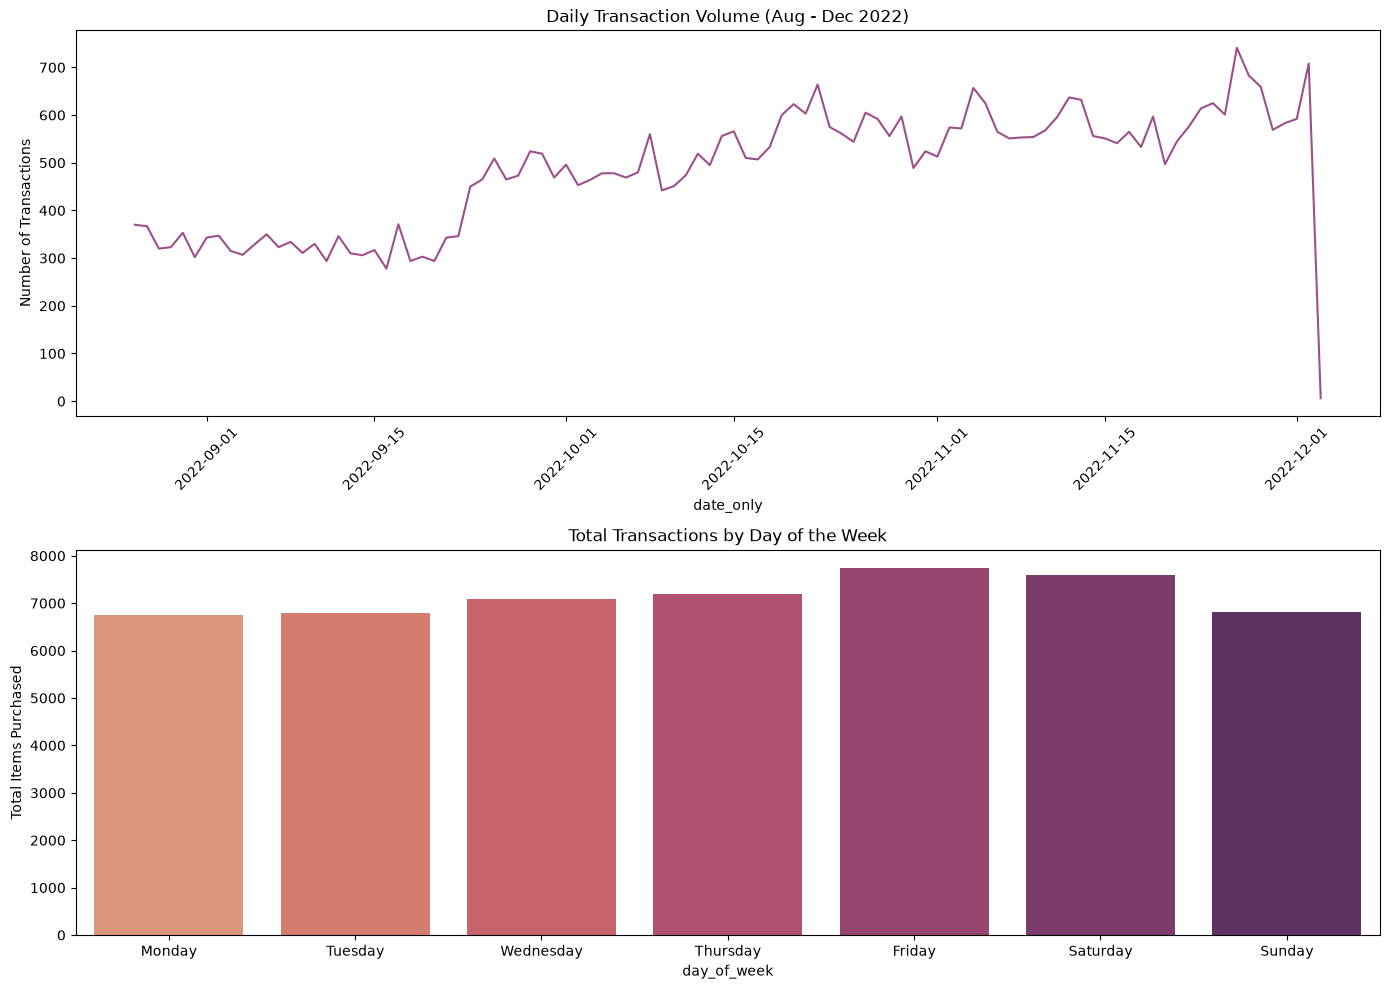

In [273]:
df['Date'] = pd.to_datetime(df['Date'])

df['day_of_week'] = df['Date'].dt.day_name()
df['month'] = df['Date'].dt.month_name()
df['date_only'] = df['Date'].dt.date 

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily Transaction Volume 
daily_volume = df.groupby('date_only')['Transaction_ID'].nunique()
sns.lineplot(x=daily_volume.index, y=daily_volume.values, ax=axes[0], color='#9d4f8c')
axes[0].set_title('Daily Transaction Volume (Aug - Dec 2022)')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Transactions by Day of the Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='day_of_week', order=day_order, ax=axes[1], palette='flare')
axes[1].set_title('Total Transactions by Day of the Week')
axes[1].set_ylabel('Total Items Purchased')

plt.tight_layout()
plt.show()

df.drop(columns=['day_of_week', 'month', 'date_only'], inplace=True)

### Standardize Column Names

In [274]:
df.columns

Index(['Unnamed: 0', 'Main_ID', 'Transaction_ID', 'Date', 'Price',
       'Code_Product', 'Amount', 'ItemKey'],
      dtype='str')

In [275]:
df.columns = (
    df.columns
    # Handle CamelCase (turns 'ItemKey' into 'Item_Key')
    .str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True) 
    
    # Replace spaces, colons, or any other non-alphanumeric character with an underscore
    .str.replace(r'[^a-zA-Z0-9]', '_', regex=True) 
    
    # Clean up any accidental double underscores (like from 'Unnamed: 0')
    .str.replace(r'_+', '_', regex=True)
    
    # Make everything lowercase
    .str.lower()
    
    # Strip any trailing or leading underscores just to be safe
    .str.strip('_') 

    # Rename 
    .str.replace(r'^code_product$', 'product_code', regex=True)
)

df.columns

Index(['unnamed_0', 'main_id', 'transaction_id', 'date', 'price',
       'product_code', 'amount', 'item_key'],
      dtype='str')

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Preprocessing</p>

<a id="2"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 2.1 Data Cleaning


### unnamed_0

In [276]:
df.drop(columns='unnamed_0', inplace=True)

## 2.2 Missing Value Analysis

In [277]:
df.isnull().sum()

main_id               0
transaction_id        0
date                  0
price                 0
product_code          0
amount                0
item_key          21403
dtype: int64

### item key

This feature is dropped and product code is used in its place.

In [278]:
df.drop(columns='item_key', inplace=True)

## 2.3 Outlier Analysis

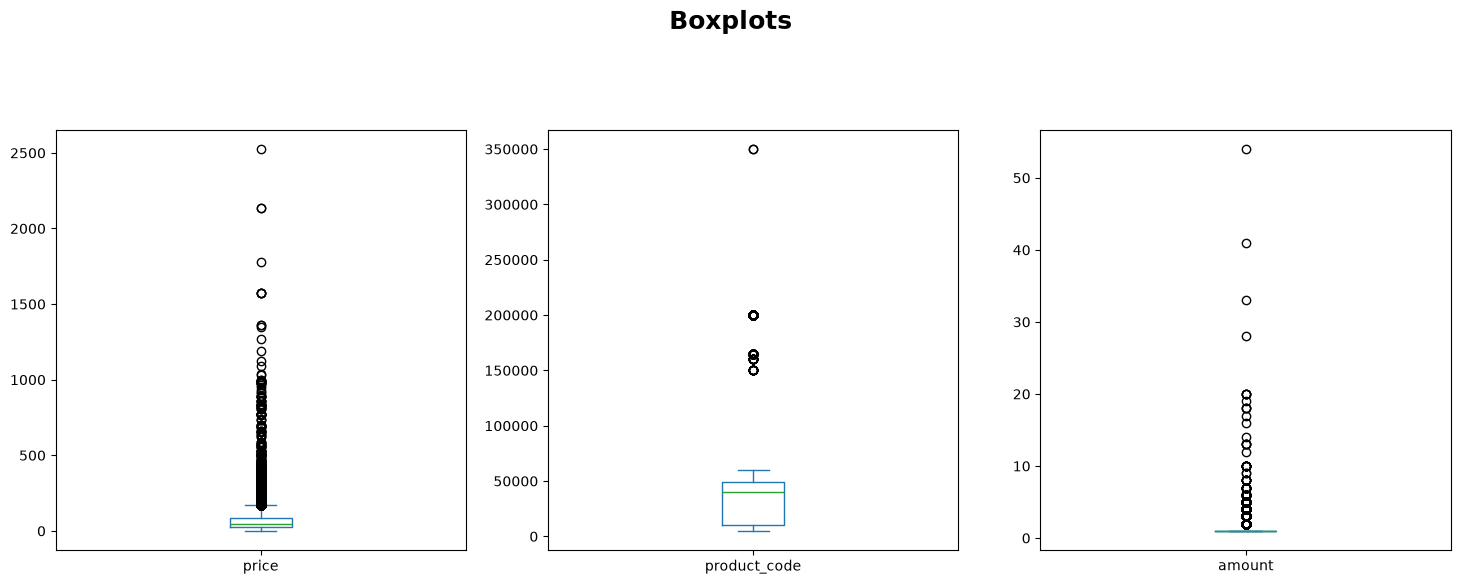

In [279]:
df.plot(kind="box", subplots=True, figsize=(18, 12), layout=(2, 3))
plt.suptitle("Boxplots", fontsize=18, fontweight="bold")
plt.show()

No way to check legitimate outliers with only product code and item key.

## 2.4 Feature Engineering

### Frequency-Based Rating

In [280]:
freq_df = df.groupby(['main_id', 'product_code']).size().reset_index(name='freq_rating')

### Spending-Based Rating

In [ ]:
df['total_spend'] = df['price'] * df['amount']

spend_df = df.groupby(['main_id', 'product_code'])['total_spend'].sum().reset_index(name='spend_rating')

# Merge the freq_df and spend_df on 'main_id' and 'product_code'
implicit_ratings = pd.merge(freq_df, spend_df, on=['main_id', 'product_code'], how='outer')

implicit_ratings.head().T

,0,1,2,3,4
main_id,00024de6,00084856,00084856,0008e848,00096930
product_code,35097.0,49291.5,49292.0,40002.0,49291.5
freq_rating,1,1,1,1,1
spend_rating,12.0,22.0,24.0,13.0,96.0


### Recency-Weighted Rating

In [282]:
# Calculate how many days ago each transaction occurred
max_date = df['date'].max()
df['days_ago'] = (max_date - df['date']).dt.days

# Apply an exponential decay
# A half-life of 30 days means a purchase 30 days ago is worth half as much as a purchase today.
half_life = 30
df['recency_weight'] = np.exp(-df['days_ago'] / half_life)

# To combine recency with the fact they purchased it, we can sum the recency weights
recency_df = df.groupby(['main_id', 'product_code'])['recency_weight'].sum().reset_index(name='recency_rating')

# Merge
implicit_ratings = pd.merge(implicit_ratings, recency_df, on=['main_id', 'product_code'], how='outer')

implicit_ratings.head().T

,0,1,2,3,4
main_id,00024de6,00084856,00084856,0008e848,00096930
product_code,35097.0,49291.5,49292.0,40002.0,49291.5
freq_rating,1,1,1,1,1
spend_rating,12.0,22.0,24.0,13.0,96.0
recency_rating,0.049787,0.40657,0.246597,0.069483,0.79189


### Hybrid Rating

In [283]:
# Normalize the ratings per user to account for power-users vs infrequent buyers
scaler = MinMaxScaler()

implicit_ratings[['freq_norm', 'spend_norm', 'recency_norm']] = scaler.fit_transform(
    implicit_ratings[['freq_rating', 'spend_rating', 'recency_rating']]
)

# Hybrid score combining normalized signals
# Adjust these weights based on what makes business sense for the food company
weight_freq = 0.4
weight_spend = 0.2
weight_recency = 0.4

implicit_ratings['hybrid_rating'] = (
    (implicit_ratings['freq_norm'] * weight_freq) +
    (implicit_ratings['spend_norm'] * weight_spend) +
    (implicit_ratings['recency_norm'] * weight_recency)
)

implicit_ratings.describe().T

,count,mean,std,min,25%,50%,75%,max
product_code,45901.0,32243.229026,21345.751041,5000.500000,10013.000000,40009.500000,49129.500000,350027.500000
freq_rating,45901.0,1.089301,0.382998,1.000000,1.000000,1.000000,1.000000,10.000000
spend_rating,45901.0,97.189560,399.529692,0.500000,26.500000,50.000000,99.000000,37026.000000
recency_rating,45901.0,0.373927,0.315477,0.036883,0.122456,0.272532,0.548812,4.316616
freq_norm,45901.0,0.009922,0.042555,0.000000,0.000000,0.000000,0.000000,1.000000
spend_norm,45901.0,0.002611,0.010791,0.000000,0.000702,0.001337,0.002660,1.000000
recency_norm,45901.0,0.078753,0.073714,0.000000,0.019995,0.055062,0.119617,1.000000
hybrid_rating,45901.0,0.035993,0.039629,0.000125,0.008570,0.023512,0.053520,0.770634


## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Exploratory Data Analysis (EDA)</p>

<a id="3"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 3.1 Data Visualization

### Top Purchased Products

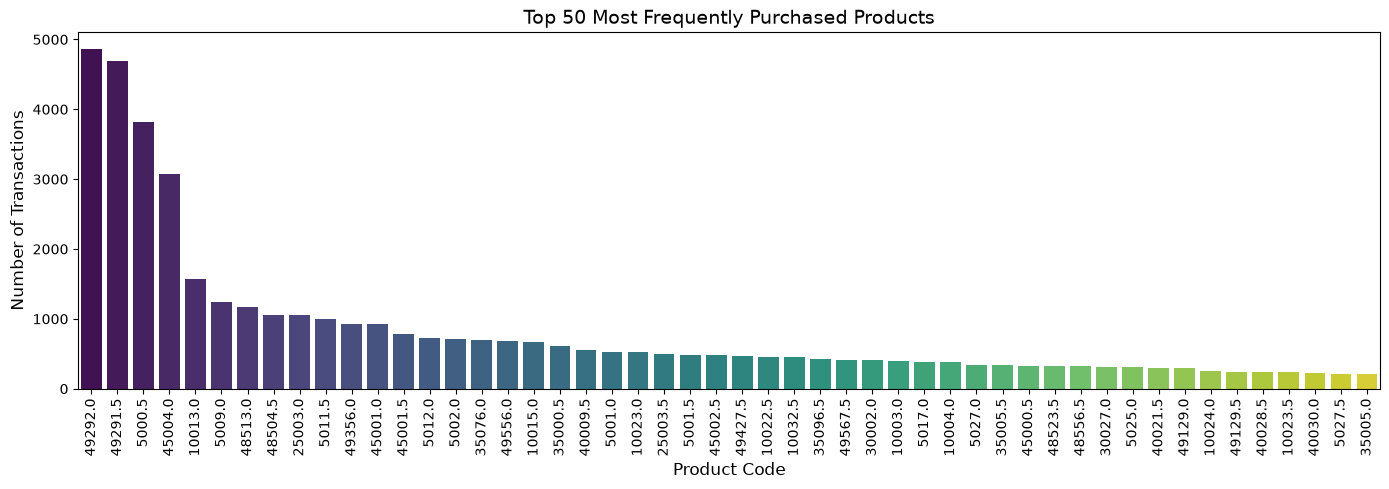

In [284]:
# Count transactions per product
item_counts = df['product_code'].value_counts()

plt.figure(figsize=(14, 5))
# Plotting the top 50 items for readability
sns.barplot(x=item_counts.index[:50].astype(str), y=item_counts.values[:50], palette='viridis')
plt.title('Top 50 Most Frequently Purchased Products', fontsize=14)
plt.xlabel('Product Code', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Transactions Per User

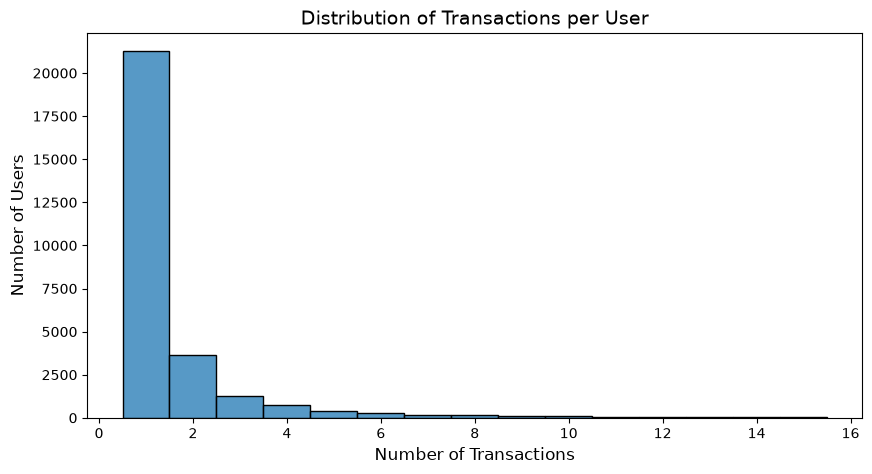

In [285]:
user_counts = df.groupby('main_id').size()

plt.figure(figsize=(10, 5))
# Focus on users with <= 15 transactions to see the distribution clearly
sns.histplot(user_counts[user_counts <= 15], bins=15, discrete=True) 
plt.title('Distribution of Transactions per User', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.show()

### Revenue vs. Volume

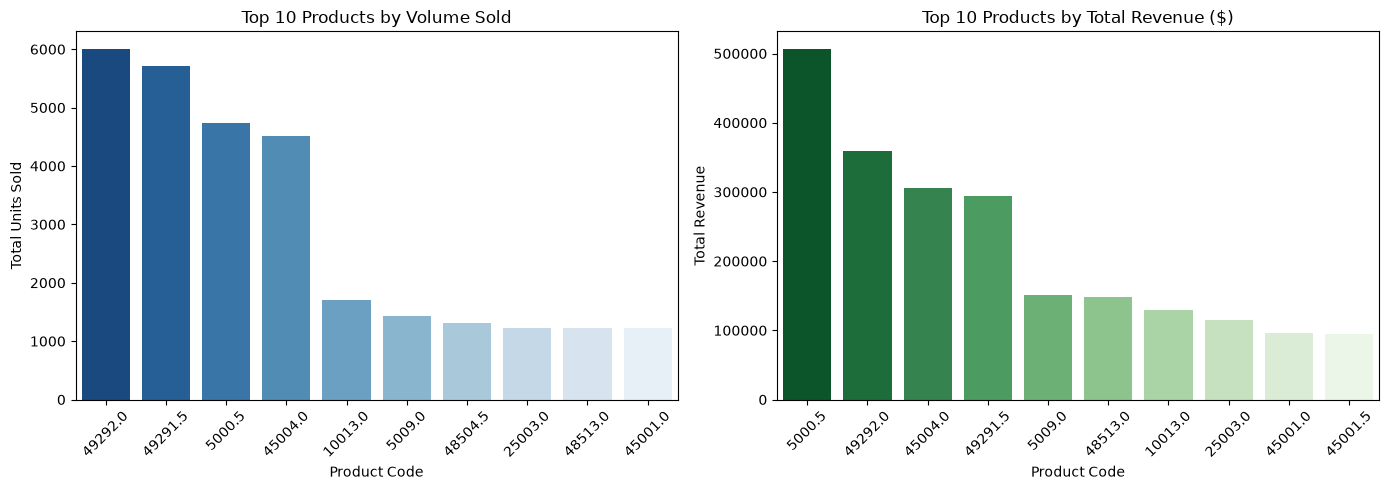

In [286]:
# Top 10 by Volume (Amount)
top_volume = df.groupby('product_code')['amount'].sum().nlargest(10)
# Top 10 by Revenue (Total Spend)
top_revenue = df.groupby('product_code')['total_spend'].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume Plot
sns.barplot(x=top_volume.index.astype(str), y=top_volume.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Products by Volume Sold')
axes[0].set_xlabel('Product Code')
axes[0].set_ylabel('Total Units Sold')
axes[0].tick_params(axis='x', rotation=45)

# Revenue Plot
sns.barplot(x=top_revenue.index.astype(str), y=top_revenue.values, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Products by Total Revenue ($)')
axes[1].set_xlabel('Product Code')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Implicit Ratings Distribution

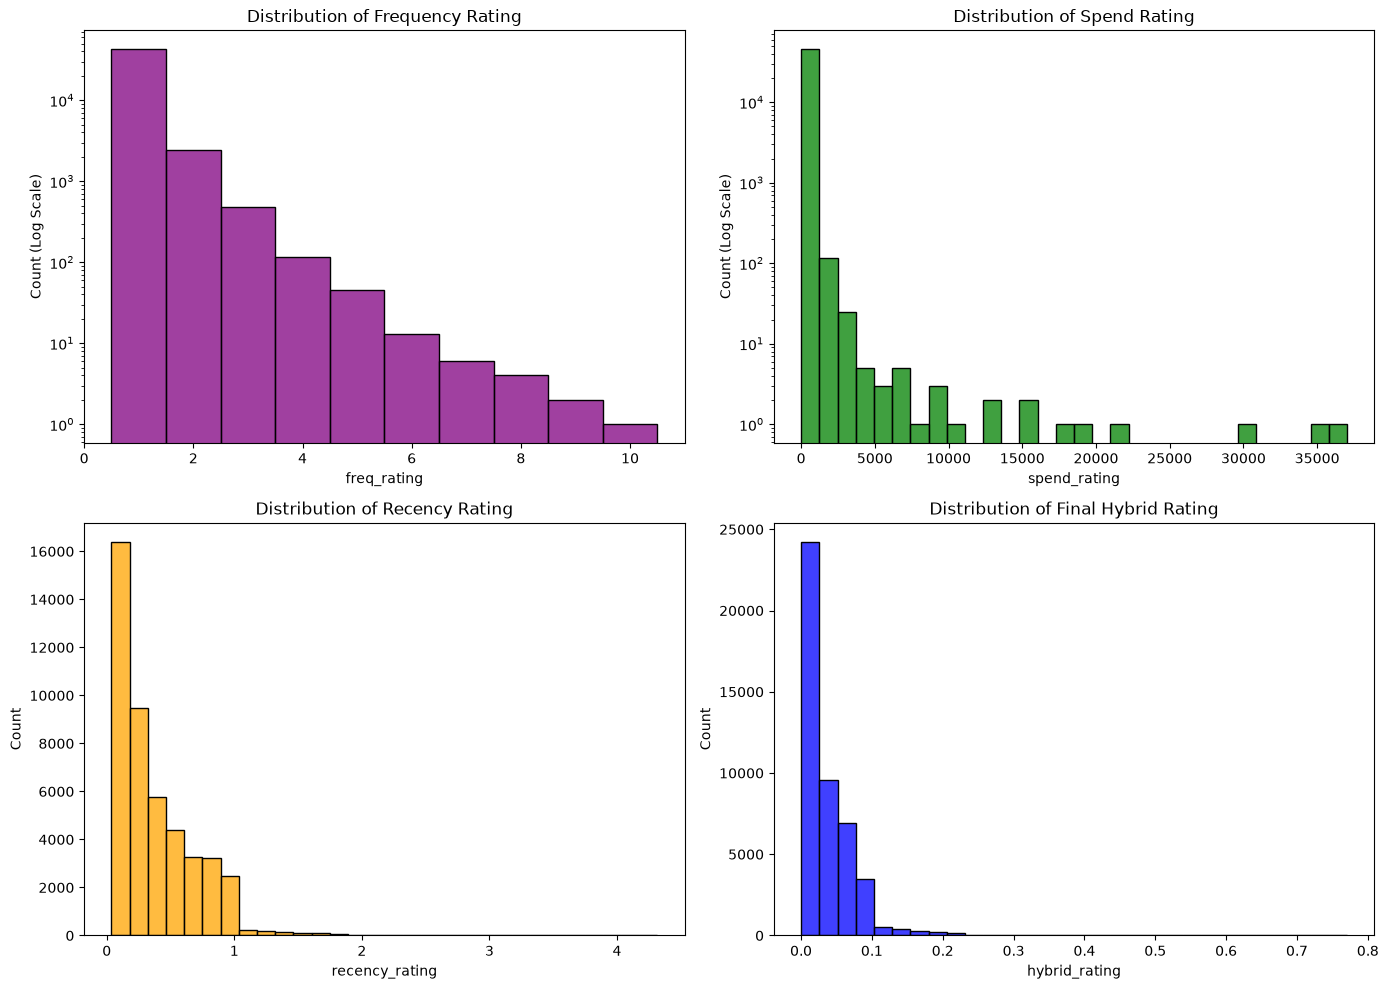

In [287]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Frequency Rating Distribution
sns.histplot(implicit_ratings['freq_rating'], bins=20, ax=axes[0,0], color='purple', discrete=True)
axes[0,0].set_title('Distribution of Frequency Rating')
axes[0,0].set_yscale('log') # Log scale handles the extreme sparsity visualization
axes[0,0].set_ylabel('Count (Log Scale)')

# 2. Spend Rating Distribution
sns.histplot(implicit_ratings['spend_rating'], bins=30, ax=axes[0,1], color='green')
axes[0,1].set_title('Distribution of Spend Rating')
axes[0,1].set_yscale('log') # Log scale
axes[0,1].set_ylabel('Count (Log Scale)')

# 3. Recency Rating Distribution
sns.histplot(implicit_ratings['recency_rating'], bins=30, ax=axes[1,0], color='orange')
axes[1,0].set_title('Distribution of Recency Rating')
axes[1,0].set_ylabel('Count')

# 4. Final Hybrid Rating Distribution
sns.histplot(implicit_ratings['hybrid_rating'], bins=30, ax=axes[1,1], color='blue')
axes[1,1].set_title('Distribution of Final Hybrid Rating')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">4. Splitting</p>

<a id="4"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>


Split the data into training and testing sets to avoid data leakage:

- **Train/Test Split:** 80/20 split.
- **Temporal Split:** Train on earlier dates, test on later dates

In [288]:
# Drop intermediate columns produced by feature engineering
df.drop(columns=['total_spend', 'days_ago', 'recency_weight'], inplace=True)

# Sort by date to ensure the split is temporal
df = df.sort_values('date')

# Use the last 20% of the timeline as the test set
split_point = int(len(df) * 0.8)
train_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">5. Recommendation</p>

<a id="5"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 5.1 Recommendation Approaches

In [289]:
def recommend_popular_dynamic(train_df, train_matrix, rating_col, user_id, k=5):
    """Recommends popular items. Safe for cold-start users."""
    popular_items = train_df.groupby('product_code')[rating_col].sum().sort_values(ascending=False).index.tolist()
    
    # Safely check for history: if the user is new, their history is an empty set
    if user_id in train_matrix.index:
        user_history = set(train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index)
    else:
        user_history = set()
        
    recs = [item for item in popular_items if item not in user_history]
    return recs[:k]

def recommend_user_based_dynamic(user_id, train_matrix, user_sim_df, train_df, rating_col, k=5, n_neighbors=10):
    """User-based CF with Popularity Fallback for cold-start users."""
    # COLD START FALLBACK
    if user_id not in train_matrix.index:
        return recommend_popular_dynamic(train_df, train_matrix, rating_col, user_id, k)
        
    similar_users = user_sim_df[user_id].sort_values(ascending=False).iloc[1:n_neighbors+1].index

    similar_users_ratings = train_matrix.loc[similar_users].mean(axis=0)
    
    user_history = set(train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index)

    similar_users_ratings = similar_users_ratings.drop(index=list(user_history), errors='ignore')

    return similar_users_ratings.sort_values(ascending=False).head(k).index.tolist()

def recommend_item_based_dynamic(user_id, train_matrix, item_sim_df, train_df, rating_col, k=5):
    """Item-based CF with Popularity Fallback for cold-start users."""
    # COLD START FALLBACK
    if user_id not in train_matrix.index:
        return recommend_popular_dynamic(train_df, train_matrix, rating_col, user_id, k)
        
    user_ratings = train_matrix.loc[user_id]

    item_scores = item_sim_df.dot(user_ratings)

    user_history = set(user_ratings[user_ratings > 0].index)

    item_scores = item_scores.drop(index=list(user_history), errors='ignore')
    
    return item_scores.sort_values(ascending=False).head(k).index.tolist()

## 5.2 Methods and Rating Comparisons

### Evaluation Function

In [ ]:
def evaluate_all_combinations(train_df, actual_purchases, rating_columns, k=5):
    summary = []
    
    for rating_col in rating_columns:
        print(f"Building matrices and evaluating for: {rating_col}...")
        
        # 1. Build the specific training matrix for this rating type
        train_matrix = train_df.pivot_table(
            index='main_id', 
            columns='product_code', 
            values=rating_col
        ).fillna(0)
        
        # 2. Compute Cosine Similarities for this specific matrix
        # Cosine similarity is best for sparse data
        user_sim_df = pd.DataFrame(
            cosine_similarity(train_matrix), 
            index=train_matrix.index, 
            columns=train_matrix.index
        )
        item_sim_df = pd.DataFrame(
            cosine_similarity(train_matrix.T), 
            index=train_matrix.columns, 
            columns=train_matrix.columns
        )
        
        # 3. Setup metric tracking dictionaries
        results = {
            'Popularity': {'precision': [], 'recall': [], 'f1': []},
            'User-Based CF': {'precision': [], 'recall': [], 'f1': []},
            'Item-Based CF': {'precision': [], 'recall': [], 'f1': []}
        }
        
        # 4. Generate recommendations and calculate metrics using ALL users
        for user in actual_purchases:
            actual = set(actual_purchases[user])
            if not actual:
                continue
                
            preds_pop = recommend_popular_dynamic(train_df, train_matrix, rating_col, user, k)
            preds_user = recommend_user_based_dynamic(user, train_matrix, user_sim_df, train_df, rating_col, k)
            preds_item = recommend_item_based_dynamic(user, train_matrix, item_sim_df, train_df, rating_col, k)
            
            for model_name, preds in zip(['Popularity', 'User-Based CF', 'Item-Based CF'], [preds_pop, preds_user, preds_item]):
                
                hits = len(set(preds).intersection(actual))
                
                precision = hits / k
                recall = hits / len(actual)
                
                # Calculate F1-Score, handling division by zero
                if (precision + recall) > 0:
                    f1 = (2 * precision * recall) / (precision + recall)
                else:
                    f1 = 0.0
                
                results[model_name]['precision'].append(precision)
                results[model_name]['recall'].append(recall)
                results[model_name]['f1'].append(f1)
                
        # 5. Aggregate the results for this rating column
        for model in results:
            summary.append({
                'Rating_Type': rating_col,
                'Model': model,
                f'Precision@{k}': np.mean(results[model]['precision']),
                f'Recall@{k}': np.mean(results[model]['recall']),
                f'F1-Score@{k}': np.mean(results[model]['f1'])
            })
            
    return pd.DataFrame(summary)

### Users for Evaluation

In [291]:
# Users who exist in BOTH the training set and the test set
# We use train_df directly instead of train_matrix
valid_users = set(train_df['main_id'].unique()).intersection(set(test_df['main_id'].unique()))

# Dictionary mapping user IDs (main_id) to their list of purchased items in the test set
actual_purchases = (
    test_df[test_df['main_id'].isin(valid_users)]
    .groupby('main_id')['product_code']
    .apply(list)
    .to_dict()
)

print(f"Number of valid users for evaluation: {len(actual_purchases)}")

# Dictionary mapping for ALL users in the test set
actual_purchases = (
    test_df.groupby('main_id')['product_code']
    .apply(list)
    .to_dict()
)

print(f"Total users for evaluation (including Cold Start): {len(actual_purchases)}")

Number of valid users for evaluation: 2283
Total users for evaluation (including Cold Start): 7043


### Add Rating to Training Data

In [292]:
# Columns to test
rating_columns_to_test = ['freq_rating', 'spend_rating', 'recency_rating', 'hybrid_rating']

# Merge implicit_ratings into train_df
train_df = pd.merge(
    train_df,
    implicit_ratings[['main_id', 'product_code'] + rating_columns_to_test],
    on=['main_id', 'product_code'],
    how='left'
)

# Check and drop duplicates just in case 
train_df = train_df.drop_duplicates(subset=['main_id', 'product_code'])

print(train_df[['main_id', 'product_code'] + rating_columns_to_test].head())

    main_id  product_code  freq_rating  spend_rating  recency_rating  \
0  fd791c5f       49567.5            1         238.0        0.036883   
1  1283bee8       10023.0            1         483.0        0.038133   
2  92113dd4      200019.5            1           6.5        0.038133   
3  bedecec3        5011.5            1          29.0        0.038133   
4  b663568c       49567.5            1          41.0        0.038133   

   hybrid_rating  
0       0.001283  
1       0.002723  
2       0.000149  
3       0.000271  
4       0.000336  


## 5.3 Final Model

In [293]:
# Define the columns to test
rating_columns_to_test = ['freq_rating', 'spend_rating', 'recency_rating', 'hybrid_rating']

# Run the evaluation
final_comparison_df = evaluate_all_combinations(
    train_df=train_df, 
    actual_purchases=actual_purchases, 
    rating_columns=rating_columns_to_test, 
    k=5
)

# Display the final comparison sorted by F1-Score
sorted_comparison = final_comparison_df.sort_values(by=f'F1-Score@5', ascending=False)
display(sorted_comparison)

Building matrices and evaluating for: freq_rating...
Building matrices and evaluating for: spend_rating...
Building matrices and evaluating for: recency_rating...
Building matrices and evaluating for: hybrid_rating...


,Rating_Type,Model,Precision@5,Recall@5,F1-Score@5
9,hybrid_rating,Popularity,0.091154,0.358185,0.139382
6,recency_rating,Popularity,0.091183,0.358071,0.139382
0,freq_rating,Popularity,0.091154,0.357947,0.139353
3,spend_rating,Popularity,0.089167,0.350439,0.136340
2,freq_rating,Item-Based CF,0.087520,0.344820,0.133997
8,recency_rating,Item-Based CF,0.084538,0.336462,0.129851
11,hybrid_rating,Item-Based CF,0.082408,0.330072,0.126901
10,hybrid_rating,User-Based CF,0.074173,0.306385,0.115451
7,recency_rating,User-Based CF,0.074031,0.307127,0.115429
1,freq_rating,User-Based CF,0.073861,0.306243,0.115204


## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">6. Conclusion</p>

<a id="6"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## Decision Log
For each consider:
1. What decision needed to be made?
2. What options did you consider?
3. What criteria did you use to evaluate options?
4. What did you choose and WHY?
5. What are the trade-offs of your choice?
6. What evidence supports your decision?

### Handling missing item key: 

* Fill NA with product code

    * Pros: Simple and retain 100% of transaction history

    * Cons: If product code shares the same ID (e.g., "12" means "apple" in item key but "bread" in code product), the recommendation algorithm will combine them

* Concatenate with product code

    * Pros: Avoids ID collisions

    * Cons: Worsen the sparsity

* **Drop and replace with product code** 

    * Pros: Simple and retain 100% of transaction history

    * Cons: Removes any way to identify specific items

### Similarity Metric

### Implicit Rating